# **Modelado**

## **Librerias**

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum
from pyspark.sql import types as T
from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split


## **Iniciamos la Sesión Spark**

In [2]:
sparks = (SparkSession.builder
         .appName("Pyspark session")
         .getOrCreate())

Creamos una sesión de spark para trabajar con los dataframes y utilizar todas las funciones de Pyspark

## **Lectura de Datos**

In [3]:
df = sparks.read.csv("accepted_2007_to_2018Q4.csv", header=True, inferSchema=True)


Cargamos los datos como un dataframe de Spark

## **Creacion Variable `default`**

In [4]:
df = df.filter((col("loan_status") == "Fully Paid") | 
               (col("loan_status") == "Charged Off"))

Filtramos los valores de **Fully Paid** y **Charged Off** de la variable `loan_status`

In [5]:
df = df.withColumn(
    "default",
    when(col("loan_status") == "Charged Off", 1).otherwise(0)
)

Definimos los valores **Charged off = 1** y **Fully Paid = 0** para la variable nueva `default` 

## **Limpieza de Nombres y Eliminacion de Variables**

In [6]:
traductor = {
    "id": "id",
    "member_id": "id_miembro",
    "loan_amnt": "monto_prestamo",
    "funded_amnt": "monto_aprobado",
    "funded_amnt_inv": "monto_inversionistas",
    "term": "plazo",
    "int_rate": "tasa_interes",
    "installment": "cuota_mensual",
    "grade": "calificacion",
    "sub_grade": "sub_calificacion",
    "emp_title": "titulo_empleo",
    "emp_length": "antiguedad_empleo",
    "home_ownership": "tenencia_vivienda",
    "annual_inc": "ingreso_anual",
    "verification_status": "estado_verificacion",
    "issue_d": "fecha_emision",
    "loan_status": "estado_prestamo",
    "pymnt_plan": "plan_pago",
    "url": "url",
    "desc": "descripcion",
    "purpose": "proposito",
    "title": "titulo_prestamo",
    "zip_code": "codigo_postal",
    "addr_state": "estado_residencia",
    "dti": "ratio_deuda_ingreso",
    "delinq_2yrs": "morosidad_2_anios",
    "earliest_cr_line": "primer_linea_credito",
    "inq_last_6mths": "consultas_ultimos6m",
    "mths_since_last_delinq": "meses_ultimo_incumplimiento",
    "mths_since_last_record": "meses_ultimo_registro",
    "open_acc": "cuentas_abiertas",
    "pub_rec": "registros_publicos",
    "revol_bal": "saldo_revolvente",
    "revol_util": "utilizacion_revolvente",
    "total_acc": "total_cuentas",
    "initial_list_status": "estado_inicial_lista",
    "out_prncp": "capital_pendiente",
    "out_prncp_inv": "capital_pendiente_inversionistas",
    "total_pymnt": "pago_total",
    "total_pymnt_inv": "pago_total_inversionistas",
    "total_rec_prncp": "capital_pagado",
    "total_rec_int": "intereses_pagados",
    "total_rec_late_fee": "mora_pagada",
    "recoveries": "recuperaciones",
    "collection_recovery_fee": "gastos_recuperacion",
    "last_pymnt_d": "fecha_ultimo_pago",
    "last_pymnt_amnt": "monto_ultimo_pago",
    "next_pymnt_d": "fecha_proximo_pago",
    "last_credit_pull_d": "fecha_ultima_consulta_credito",
    "collections_12_mths_ex_med": "cobranzas_12m_excl_med",
    "mths_since_last_major_derog": "meses_ultimo_informe_negativo",
    "policy_code": "codigo_politica",
    "application_type": "tipo_aplicacion",
    "annual_inc_joint": "ingreso_anual_conjunto",
    "dti_joint": "ratio_deuda_ingreso_conjunto",
    "verification_status_joint": "estado_verificacion_conjunto",
    "acc_now_delinq": "cuentas_en_morosidad",
    "tot_coll_amt": "monto_total_cobranzas",
    "tot_cur_bal": "saldo_total_actual",
    "open_acc_6m": "cuentas_abiertas_6m",
    "open_il_6m": "cuentas_instalacion_6m",
    "open_il_12m": "cuentas_instalacion_12m",
    "open_il_24m": "cuentas_instalacion_24m",
    "mths_since_rcnt_il": "meses_ultima_cuenta_instalacion",
    "total_bal_il": "saldo_total_instalacion",
    "il_util": "utilizacion_instalacion",
    "open_rv_12m": "cuentas_revolving_12m",
    "open_rv_24m": "cuentas_revolving_24m",
    "max_bal_bc": "saldo_max_tarjeta",
    "all_util": "utilizacion_total",
    "total_rev_hi_lim": "limite_total_revolving",
    "inq_fi": "consultas_financieras",
    "total_cu_tl": "total_lineas_credito",
    "inq_last_12m": "consultas_12m",
    "acc_open_past_24mths": "cuentas_abiertas_24m",
    "avg_cur_bal": "saldo_promedio_actual",
    "bc_open_to_buy": "credito_disponible_bc",
    "bc_util": "utilizacion_tarjetas_bc",
    "chargeoff_within_12_mths": "castigos_12m",
    "delinq_amnt": "monto_morosidad",
    "mo_sin_old_il_acct": "meses_cuenta_instalacion_mas_antigua",
    "mo_sin_old_rev_tl_op": "meses_cuenta_revolving_mas_antigua",
    "mo_sin_rcnt_rev_tl_op": "meses_ultima_cuenta_revolving",
    "mo_sin_rcnt_tl": "meses_ultima_linea_credito",
    "mort_acc": "cuentas_hipotecarias",
    "mths_since_recent_bc": "meses_ultima_tarjeta_bc",
    "mths_since_recent_bc_dlq": "meses_mora_tarjeta_bc",
    "mths_since_recent_inq": "meses_ultima_consulta",
    "mths_since_recent_revol_delinq": "meses_mora_revolving",
    "num_accts_ever_120_pd": "cuentas_mas_120_dias",
    "num_actv_bc_tl": "cuentas_bc_activas",
    "num_actv_rev_tl": "cuentas_revolving_activas",
    "num_bc_sats": "cuentas_bc_satisfechas",
    "num_bc_tl": "cuentas_bc_totales",
    "num_il_tl": "cuentas_instalacion_totales",
    "num_op_rev_tl": "cuentas_revolving_abiertas",
    "num_rev_accts": "cuentas_revolving",
    "num_rev_tl_bal_gt_0": "cuentas_revolving_saldo_gt_0",
    "num_sats": "cuentas_satisfechas",
    "num_tl_120dpd_2m": "cuentas_120_dias_2m",
    "num_tl_30dpd": "cuentas_30_dias",
    "num_tl_90g_dpd_24m": "cuentas_90_dias_24m",
    "num_tl_op_past_12m": "cuentas_abiertas_12m",
    "pct_tl_nvr_dlq": "pct_lineas_nunca_mora",
    "percent_bc_gt_75": "pct_bc_utilizacion_gt_75",
    "pub_rec_bankruptcies": "bancarrotas_publicas",
    "tax_liens": "gravamenes_impuestos",
    "tot_hi_cred_lim": "limite_total_credito_alto",
    "total_bal_ex_mort": "saldo_total_ex_mortgage",
    "total_bc_limit": "limite_total_bc",
    "total_il_high_credit_limit": "limite_total_instalacion_alto",
    "revol_bal_joint": "saldo_revolving_conjunto",
    "sec_app_fico_range_low": "fico_bajo_codeudor",
    "sec_app_fico_range_high": "fico_alto_codeudor",
    "sec_app_earliest_cr_line": "primer_credito_codeudor",
    "sec_app_inq_last_6mths": "consultas_6m_codeudor",
    "sec_app_mort_acc": "cuentas_hipoteca_codeudor",
    "sec_app_open_acc": "cuentas_abiertas_codeudor",
    "sec_app_revol_util": "utilizacion_revolving_codeudor",
    "sec_app_open_il_6m": "instalacion_6m_codeudor",
    "sec_app_num_rev_accts": "num_revolving_codeudor",
    "sec_app_chargeoff_within_12_mths": "castigos_12m_codeudor",
    "sec_app_collections_12_mths_ex_med": "cobranzas_12m_excl_med_codeudor",
    "sec_app_mths_since_last_major_derog": "meses_incumplimiento_codeudor",
    "hardship_flag": "bandera_dificultad",
    "hardship_type": "tipo_dificultad",
    "hardship_reason": "razon_dificultad",
    "hardship_status": "estado_dificultad",
    "deferral_term": "plazo_prorroga",
    "hardship_amount": "monto_dificultad",
    "hardship_start_date": "fecha_inicio_dificultad",
    "hardship_end_date": "fecha_fin_dificultad",
    "payment_plan_start_date": "fecha_inicio_plan_pago",
    "hardship_length": "duracion_dificultad",
    "hardship_dpd": "dias_mora_dificultad",
    "hardship_loan_status": "estado_prestamo_dificultad",
    "orig_projected_additional_accrued_interest": "interes_proyectado_adicional",
    "hardship_payoff_balance_amount": "monto_saldo_pago_dificultad",
    "hardship_last_payment_amount": "monto_ultimo_pago_dificultad",
    "disbursement_method": "metodo_desembolso",
    "debt_settlement_flag": "bandera_acuerdo_deuda",
    "debt_settlement_flag_date": "fecha_bandera_acuerdo_deuda",
    "settlement_status": "estado_acuerdo",
    "settlement_date": "fecha_acuerdo",
    "settlement_amount": "monto_acuerdo",
    "settlement_percentage": "porcentaje_acuerdo",
    "settlement_term": "plazo_acuerdo",
    "default": "incumplimiento"
}
for col_old, col_new in traductor.items():
    if col_old in df.columns:
        df = df.withColumnRenamed(col_old, col_new)

Hacemos el cambio de las variables a español 

In [7]:
registros = df.count()
variables = len(df.columns)

missing_df = df.select([
    sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
])

missing_pd = missing_df.toPandas().T
missing_pd.columns = ["nulos"]
missing_pd["%_faltantes"] = (missing_pd["nulos"] / registros) * 100
missing_pd = missing_pd.sort_values("%_faltantes", ascending=False)

v_elim = missing_pd[missing_pd["%_faltantes"] > 40].index.tolist()
df = df.drop(*v_elim)

v_elim2 = ["id","monto_aprobado","estado_prestamo","monto_inversionistas", "titulo_empleo", "url", "titulo_prestamo", "pago_total", 
           "pago_total_inversionistas", "capital_pagado", "intereses_pagados", "mora_pagada", "recuperaciones", "gastos_recuperacion", 
           "fecha_ultimo_pago", "fecha_ultima_consulta_credito", "bandera_acuerdo_deuda", "capital_pendiente_inversionistas","calificacion", 
           "monto_ultimo_pago", "codigo_politica"]
df = df.drop(*v_elim2)

Asignamos algunas variables para utilizarlas mas adelante en el modelo y eliminamos variables que no utilizaremos y encontramos irrelevantes

## **Partición de Datos de scikit y Pyspark antes de imputación para evitar Data Leakage**

### Seleccionamos las variables relevantes para el estudio

In [8]:
features = [
    "monto_prestamo",
    "tasa_interes",
    "cuota_mensual",
    "ingreso_anual",
    "antiguedad_empleo",
    "proposito",
    "plazo", 
    "tenencia_vivienda",
    "estado_verificacion",
    "sub_calificacion",
    "estado_residencia",
    "cuentas_abiertas_12m",
    "pct_lineas_nunca_mora",
    "ratio_deuda_ingreso",
    "last_fico_range_high"
    ]

target = "incumplimiento"

Escogemos las variables de interés para modelar y las separamos en `features` que son las variables predictoras y `target` que es la variable a predecir

### Definimos el dataset con las variables a trabajar

In [9]:
df = df.select(features + [target])

Creamos el Dataset solo con estas variables que utilizaremos para el proyecto

### Separamos las variables predictoras y la objetivo

In [10]:
X = df[features]
y = df[target]

Separamos en vectores **X** las variables predictoras y **y** la predictora

#### Tomamos una muestra y transformamos a pandas para trabajar scikit

In [11]:
sample_X = X.sample(False, 0.05, seed=42).toPandas()


In [12]:
sample_y = df.sample(False, 0.05, seed=42).select(target).toPandas()

Debido a la cantidad de los datos, por motivos de RAM y almacenamiento hay que utilizar una muestra para modelar en Scikit

### Split scikit

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    sample_X, sample_y, test_size=0.2, random_state=42, stratify=sample_y
)

### Split Pyspark

In [14]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)    

Realizamos el Split en ambos modelos 

## Scikit.learn

### Librerias Necesarias

In [15]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


Estas son las librerias que se utilizaran solo en el modelo de Scikit-Learn

### Visualizamos las variables que aún tiene valores faltantes y estan presentes en el dataset 

In [16]:
missing_pd = missing_df.toPandas().T
missing_pd.columns = ["nulos"]
missing_pd["%_faltantes"] = (missing_pd["nulos"] / registros) * 100
missing_pd = missing_pd.sort_values("%_faltantes", ascending=False)
missing_pd.head(60)

,nulos,%_faltantes
id_miembro,1345309,100.000000
fecha_proximo_pago,1345086,99.983424
interes_proyectado_adicional,1341548,99.720436
monto_saldo_pago_dificultad,1339554,99.572217
monto_ultimo_pago_dificultad,1339554,99.572217
dias_mora_dificultad,1339550,99.571920
estado_prestamo_dificultad,1339548,99.571771
fecha_inicio_dificultad,1339547,99.571697
fecha_fin_dificultad,1339546,99.571623
duracion_dificultad,1339545,99.571548


Revisamos nuevamente las variables con valores faltantes para decidir como imputar

### Seleccionamos las variables con mas de 5% de valores faltantes para realizar la imputación

In [17]:
NUMERIC_TYPES = (T.ByteType, T.ShortType, T.IntegerType, T.LongType,
                 T.FloatType, T.DoubleType, T.DecimalType)

def get_numeric_cols(df):
    return [f.name for f in df.schema.fields if isinstance(f.dataType, NUMERIC_TYPES)]

def get_categorical_cols(df, ignore=None):
    ignore = set(ignore or [])
    cat_cols = []
    for field in df.schema.fields:  # aquí recorres StructField, no strings
        if field.name not in ignore and isinstance(field.dataType, (T.StringType, T.BooleanType)):
            cat_cols.append(field.name)
    return cat_cols


def jarque_bera(n, skew, kurt):
    # JB = n/6*(skew^2 + (kurt-3)^2/4)
    if n is None or n == 0 or skew is None or kurt is None:
        return None
    return (n/6.0) * (skew**2 + ((kurt - 3.0)**2)/4.0)

# --- imputación principal ---
def impute_spark(df, cat_strategy="mode", verbose=True):
    """
    Imputa:
      - Numéricas: media si JB < 5.99 (≈normal), si no mediana (approxQuantile)
      - Categóricas: moda
    Devuelve df_imputado y un dict con el valor usado por columna.
    """
    fill_map = {}

    # ===== NUMÉRICAS =====
    num_cols = get_numeric_cols(df)
    for col in num_cols:
        # conteo no nulo + momentos
        stats = df.select(
            F.count(F.col(col)).alias("n_valid"),
            F.mean(F.col(col)).alias("mean"),
            F.skewness(F.col(col)).alias("skew"),
            F.kurtosis(F.col(col)).alias("kurt")
        ).first()

        n_valid = stats["n_valid"]
        if n_valid == 0:
            if verbose: print(f"[{col}] solo NA, se omite imputación.")
            continue

        mean = stats["mean"]
        skew = stats["skew"]
        kurt = stats["kurt"]

        JB = jarque_bera(n_valid, skew, kurt)
        # Umbral χ²(2) 0.95 ≈ 5.99  → JB < 5.99 ⇒ no rechazamos normalidad
        is_normal = (JB is not None) and (JB < 5.99)

        if is_normal and mean is not None:
            value = float(mean)
            metodo = "media (JB < 5.99)"
        else:
            # mediana robusta con approxQuantile
            value = df.approxQuantile(col, [0.5], 0.001)[0]
            metodo = "mediana (JB ≥ 5.99 o momentos no disponibles)"

        fill_map[col] = value
        if verbose:
            print(f"[{col}] imputará con {metodo}; N={n_valid}; valor={value}")

    # ===== CATEGÓRICAS =====
    cat_cols = get_categorical_cols(df, ignore=num_cols)
    for col in cat_cols:
        if cat_strategy == "mode":
            # moda: valor más frecuente (ignorando NULL)
            row = (df.where(F.col(col).isNotNull())
                     .groupBy(col).count()
                     .orderBy(F.desc("count"))
                     .limit(1)
                     .collect())
            if row:
                value = row[0][0]
                fill_map[col] = value
                if verbose:
                    print(f"[{col}] imputará con moda: {value}")
            else:
                if verbose:
                    print(f"[{col}] todos NA, se omite imputación.")
        else:
            raise ValueError("cat_strategy no soportada. Usa 'mode'.")

    # Aplicar imputación en un solo paso
    df_imputed = df.fillna(fill_map)
    return df_imputed, fill_map


#### Realizamos imputaciones

In [18]:
df_imputed, fill_values = impute_spark(df, cat_strategy="mode", verbose=True)
df_imputed.show()

[monto_prestamo] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=12000.0
[tasa_interes] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=12.74
[cuota_mensual] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=375.33
[cuentas_abiertas_12m] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1277784; valor=2.0
[pct_lineas_nunca_mora] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1277628; valor=98.0
[incumplimiento] imputará con mediana (JB ≥ 5.99 o momentos no disponibles); N=1345309; valor=0.0
[ingreso_anual] imputará con moda: 60000.0
[antiguedad_empleo] imputará con moda: 10+ years
[proposito] imputará con moda: debt_consolidation
[plazo] imputará con moda:  36 months
[tenencia_vivienda] imputará con moda: MORTGAGE
[estado_verificacion] imputará con moda: Source Verified
[sub_calificacion] imputará con moda: C1
[estado_residencia] imputará con moda: CA
[ratio_deuda_ingreso] im

Realizamos la imputacion de las variables aún con valores faltantes

### Comprobamos las imputaciones

In [19]:
df_imputed.printSchema()

root
 |-- monto_prestamo: double (nullable = false)
 |-- tasa_interes: double (nullable = false)
 |-- cuota_mensual: double (nullable = false)
 |-- ingreso_anual: string (nullable = false)
 |-- antiguedad_empleo: string (nullable = false)
 |-- proposito: string (nullable = false)
 |-- plazo: string (nullable = false)
 |-- tenencia_vivienda: string (nullable = false)
 |-- estado_verificacion: string (nullable = false)
 |-- sub_calificacion: string (nullable = false)
 |-- estado_residencia: string (nullable = false)
 |-- cuentas_abiertas_12m: double (nullable = false)
 |-- pct_lineas_nunca_mora: double (nullable = false)
 |-- ratio_deuda_ingreso: string (nullable = false)
 |-- last_fico_range_high: string (nullable = false)
 |-- incumplimiento: integer (nullable = false)



Hacemos la verificación de las imputaciones

### Definimos nuevamente el dataset

In [20]:
df = df_imputed

Cambiamos el Dataset listo para modelar con las variables relevantes

### Verificamos que esten todas las columnas para evitar errores en el preprocesamiento

In [21]:
missing = [c for c in features + [target] if c not in df.columns]
if missing:
    print(f"Faltan columnas en df: {missing}")

### Hacemos nuevamente las muestras ya imputadas

In [22]:
X = df[features]
y = df[target]

Definimos nuevamente los datasets con las imputaciones

In [23]:
sample_X = X.sample(False, 0.05, seed=42).toPandas()

sample_y = df.sample(False, 0.05, seed=42).select(target).toPandas()

Sacamos las muestras de ambas para modelar en scikit, debido a la cantidad masiva de datos

### Separamos las variables numericas y categoricas predictoras

In [24]:
xv_num = [c for c, t in X.dtypes if t in ("int", "double", "float")]
xv_cat = [i for i, t in X.dtypes if t == "string"]

Definimos `xv_num` como las variables numéricas y `xv_cat` como las variables categoricas, ambas de las variables predictoras

### Pipeline Preprocesamiento

In [25]:
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler(with_mean=False))
])
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

In [26]:
prep = ColumnTransformer(transformers=[
    ("num", num_pipeline, xv_num),
    ("cat", cat_pipeline, xv_cat)
], 
sparse_threshold=1.0,
remainder="drop")

Creamos los Pipelines de preprocesamiento 

In [27]:
start = time.time()
X_pre = prep.fit_transform(sample_X)
preproc_time = time.time() - start
print(f"Preprocesamiento completado en {preproc_time:.2f}s")
print("X_pre shape:", X_pre.shape)

Preprocesamiento completado en 0.43s
X_pre shape: (67225, 11037)


Aplicamos el preprocesamiento a la muestra a modelar `sample_X`

### RandomForest

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipe = Pipeline([
    ("prep", prep),     
    ("clf", rf)         
])

param_grid = {
    "clf__n_estimators": [10, 50, 100],
    "clf__max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    pipe, param_grid,
    cv=3, scoring="f1", n_jobs=-4, verbose=2
)

t0 = time.time()
grid.fit(sample_X, sample_y)   
train_time = time.time() - t0

print(f"GridSearch entrenado en {train_time:.2f}s")
print("Mejores params:", grid.best_params_, "Mejor score (f1):", grid.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
GridSearch entrenado en 15.01s
Mejores params: {'clf__max_depth': 15, 'clf__n_estimators': 10} Mejor score (f1): 0.00544203339143812


c:\Users\mming\miniconda3\envs\data_viz_k\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Definimos el modelo **RandomForest** y aplicamos el modelo con los pipelines dentro de cada paso del modelo

### Entrenamiento de todo Train y Test

In [29]:
b_params = grid.best_params_
rf_params = {k.split("__", 1)[1]: v
             for k, v in grid.best_params_.items()
             if k.startswith("clf__")}
b_rf = RandomForestClassifier(
    **rf_params,
    random_state=42,
    n_jobs=4
)

b_pipe = Pipeline([
    ("prep", prep),     
    ("clf", b_rf)         
])


t0 = time.time()
b_pipe.fit(X_train, y_train)
full_train_time = time.time() - t0
print(f"El tiempo del entrenamiento en todo el train fue {full_train_time:.2f}s")


t0 = time.time()
pred_y = b_pipe.predict(X_test)
pred_time = time.time() - t0

pro_y = b_pipe.predict_proba(X_test)[:, 1]



c:\Users\mming\miniconda3\envs\data_viz_k\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


El tiempo del entrenamiento en todo el train fue 0.43s


Utilizamos los mejores parámetros que nos dio el modelo RandomForest de la celda anterior

### Resultados

In [30]:
metricas = {
    "accuracy": accuracy_score(y_test, pred_y),
    "precision": precision_score(y_test, pred_y, zero_division=0),
    "recall": recall_score(y_test, pred_y, zero_division=0),
    "f1": f1_score(y_test, pred_y, zero_division=0),
    "roc_auc": roc_auc_score(y_test, pro_y),
    "grid_time_s": train_time,
    "train_time_s": full_train_time,
    "pred_time_s": pred_time
}

print("\n[RESULTADOS sklearn]:")
for k,v in metricas.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_y))
print("\nReporte de clasificación:\n", classification_report(y_test, pred_y, zero_division=0))


[RESULTADOS sklearn]:
accuracy: 0.7990
precision: 1.0000
recall: 0.0022
f1: 0.0044
roc_auc: 0.8461
grid_time_s: 15.0100
train_time_s: 0.4318
pred_time_s: 0.0965

Confusion matrix:
 [[10737     0]
 [ 2702     6]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     10737
           1       1.00      0.00      0.00      2708

    accuracy                           0.80     13445
   macro avg       0.90      0.50      0.45     13445
weighted avg       0.84      0.80      0.71     13445



### Curva ROC

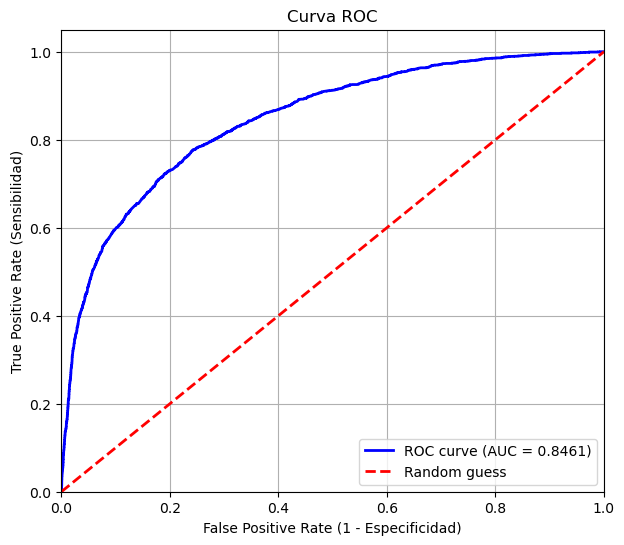

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, pro_y)


roc_auc = auc(fpr, tpr)


plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Modelo Pyspark

### Librerias Necesarias

In [32]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import DoubleType
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer as SparkImputer
from pyspark.ml import Pipeline as SparkPipeline
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

#### Seleccionamos dataset
Aunque ya se realizo la carga de los datos, seleccionaremos solo las que vamos a utilizar en spark

In [33]:
sdf = df.select(*(features + [target]))
NUM_TYPES = (T.ByteType, T.ShortType, T.IntegerType, T.LongType, T.FloatType, T.DoubleType, T.DecimalType)
xv_num = [f.name for f in sdf.schema.fields if f.name in features and isinstance(f.dataType, NUM_TYPES)]
xv_cat = [f.name for f in sdf.schema.fields if f.name in features and isinstance(f.dataType, (T.StringType, T.BooleanType))]
for c in xv_num:
    sdf = sdf.withColumn(c, F.col(c).cast(T.DoubleType()))

### StringIndexer y OneHotEncoder

In [34]:
label_idx = StringIndexer(inputCol=target, outputCol="label", handleInvalid="keep")

imputer = SparkImputer(
    inputCols=xv_num,
    outputCols=[c + "_imp" for c in xv_num]
)
try:
    imputer.setStrategy("median")
except Exception:
    imputer.setStrategy("mean")

indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in xv_cat]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_oh", dropLast=True) for c in xv_cat]

### VectorAssemble

In [35]:
assembler_inputs = [c + "_imp" for c in xv_num] + [c + "_oh" for c in xv_cat]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip")

### Spark Pipelines

In [36]:
spark_pipe = SparkPipeline(stages=[label_idx, imputer] + indexers + encoders + [assembler])

### Preprocesamiento 

In [37]:
t0 = time.time()
model_pipe = spark_pipe.fit(sdf)
sdf_pre = model_pipe.transform(sdf).select("features", F.col("label"))
t_spark_pre = time.time() - t0


In [38]:
print(f"Preprocesamiento Spark completado en {t_spark_pre:.2f}s")
sdf_pre.show(5, truncate=False)

Preprocesamiento Spark completado en 26.13s
+------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                              |label|
+------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|(72363,[0,1,2,3,4,13,64367,64378,64617,64619,64627,64634,64669,67329,72198],[3600.0,13.99,123.03,3.0,76.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])   |0.0  |
|(72363,[0,1,2,3,4,7,64367,64384,64617,64619,64627,64628,64708,65206,72164],[24700.0,11.99,820.28,2.0,97.4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])   |0.0  |
|(72363,[0,1,2,4,45,64367,64380,64618,64619,64627,64629,64667,65757,72165],[20000.0,10.78,432.66,100.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])       |0.0  |
|(

### Definimos Nuevamente el Dataset

In [39]:
sdf = sdf_pre

### Muestra Pyspark

In [40]:
target_size = 70000   
fraction = min(1.0, target_size / train_df.count())
train_mu = train_df.sample(False, fraction, seed=42)

### Modelado

In [41]:
for c in xv_num:
    train_df = train_df.withColumn(c, F.col(c).cast(T.DoubleType()))
    test_df  = test_df.withColumn(c,  F.col(c).cast(T.DoubleType()))

In [42]:
# Parámetros del RandomForest
param_grid = {
    "numTrees": [10, 50, 100],   
    "maxDepth": [5, 10, 15]
}

evaluator_ = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

results = []
best_model = None
best_auc = -1
best_preds = None

### RandomForest

In [43]:
prep_stages = [label_idx , imputer] + indexers + encoders + [assembler]

In [44]:
sdf.select("label").distinct().show()


+-----+
|label|
+-----+
|  0.0|
|  1.0|
+-----+



imputer = SparkImputer(
    inputCols=xv_num,
    outputCols=[f"{c}_imp" for c in xv_num]
).setStrategy("median")  # o "mean"

# 3) Indexación de categóricas (requerido antes de OHE)
cat_input_idx  = [c for c in xv_cat]
cat_output_idx = [f"{c}_idx" for c in xv_cat]
idx = StringIndexer(
    inputCols=cat_input_idx,
    outputCols=cat_output_idx,
    handleInvalid="keep"              # no fallar si aparece categoría nueva
)

# 4) One-Hot Encoder (en modo multicolumna)
cat_output_ohe = [f"{c}_oh" for c in xv_cat]
ohe = OneHotEncoder(
    inputCols=cat_output_idx,
    outputCols=cat_output_ohe,
    dropLast=True,                    # convención habitual
    handleInvalid="keep"
)

# 5) Ensamble de features: numéricas imputadas + categóricas OHE
assembler_inputs = [f"{c}_imp" for c in xv_num] + cat_output_ohe
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="skip"
)

# 6) Clasificador
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",  # usamos directamente 'features' (ya con OHE)
    numTrees=100,
    maxDepth=10,
    seed=42
    # maxBins puede ser menor con OHE porque todo es 0/1
)

# 7) Pipeline completo (si tu label venía como 0/1 no incluyas label_idx)
stages = [label_idx, imputer, idx, ohe, assembler, rf]
# Si tu target fuera texto, usa: stages = [label_idx, imputer, idx, ohe, assembler, rf]

pipe = SparkPipeline(stages=stages)

# 8) Entrenamiento y evaluación
model = pipe.fit(train_mu)           # usa tu split 80/20
preds  = model.transform(test_df)

evaluator_ = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",   # por defecto, longitud 2 (OK para AUC)
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(preds)
print("AUC:", auc)

In [45]:
for ntrees in param_grid["numTrees"]:
    for depth in param_grid["maxDepth"]:
        print(f"[INFO] Entrenando con numTrees={ntrees}, maxDepth={depth}")

        # Definir el pipeline completo: preprocesamiento + modelo
        pipe = SparkPipeline(stages=prep_stages + [
            RandomForestClassifier(
                featuresCol="features",
                labelCol="label",
                numTrees=ntrees,
                maxDepth=depth,
                seed=42
            )
        ])

        # Entrenamiento
        t0 = time.time()
        model_pipe = pipe.fit(train_mu)   
        train_time = time.time() - t0

        # Predicciones
        t0 = time.time()
        preds = model_pipe.transform(test_df)
        pred_time = time.time() - t0

        # Evaluación
        auc = evaluator.evaluate(preds)   # BinaryClassificationEvaluator
        print(f"AUC={auc:.4f}, train_time={train_time:.2f}s, pred_time={pred_time:.2f}s")

        # Guardar resultados
        results.append((ntrees, depth, auc, train_time, pred_time))

        if auc > best_auc:
            best_auc = auc
            best_model = model_pipe
            best_preds = preds

print("Mejor modelo encontrado:")
print(best_model)
print(f"AUC ROC = {best_auc:.4f}")

[INFO] Entrenando con numTrees=10, maxDepth=5
AUC=0.7117, train_time=66.98s, pred_time=0.38s
[INFO] Entrenando con numTrees=10, maxDepth=10
AUC=0.7117, train_time=83.29s, pred_time=0.31s
[INFO] Entrenando con numTrees=10, maxDepth=15
AUC=0.7118, train_time=103.99s, pred_time=0.41s
[INFO] Entrenando con numTrees=50, maxDepth=5
AUC=0.7117, train_time=93.48s, pred_time=0.39s
[INFO] Entrenando con numTrees=50, maxDepth=10
AUC=0.7117, train_time=162.19s, pred_time=0.31s
[INFO] Entrenando con numTrees=50, maxDepth=15
AUC=0.7117, train_time=246.13s, pred_time=0.44s
[INFO] Entrenando con numTrees=100, maxDepth=5
AUC=0.7117, train_time=160.37s, pred_time=0.51s
[INFO] Entrenando con numTrees=100, maxDepth=10
AUC=0.7117, train_time=274.68s, pred_time=0.29s
[INFO] Entrenando con numTrees=100, maxDepth=15
AUC=0.7117, train_time=417.93s, pred_time=0.34s
Mejor modelo encontrado:
PipelineModel_28aa63019691
AUC ROC = 0.7118


### Vector Probabilidad

In [46]:
prob1 = F.udf(lambda v: float(v[1]), DoubleType())

scored = (preds
          .withColumn("y_true", F.col("label").cast("double"))
          .withColumn("y_pred", F.col("prediction").cast("double"))
          .withColumn("y_score", prob1("probability"))
          .select("y_true", "y_pred", "y_score"))

In [47]:
cm = (scored
      .groupBy("y_true", "y_pred")
      .count()
      .cache())

def pick(df, t, p):
    row = df.filter((F.col("y_true")==t) & (F.col("y_pred")==p)).select("count").first()
    return row[0] if row else 0

tp = pick(cm, 1.0, 1.0)
tn = pick(cm, 0.0, 0.0)
fp = pick(cm, 0.0, 1.0)
fn = pick(cm, 1.0, 0.0)

total = tp + tn + fp + fn
accuracy  = (tp + tn) / total if total else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall    = tp / (tp + fn) if (tp + fn) else 0.0
f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0

print(f"accuracy={accuracy:.4f}, precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}")

accuracy=0.8004, precision=0.0000, recall=0.0000, f1=0.0000


In [48]:
from pyspark.sql import functions as F
import pandas as pd

scored = preds.select(
    F.col("label").cast("double").alias("y_true"),
    F.col("prediction").cast("double").alias("y_pred"),
    vector_to_array("probability").getItem(1).cast("double").alias("y_score")  # prob de la clase 1
).cache()

N_MAX = 1000
rows = (scored
        .orderBy(F.rand(42))
        .limit(N_MAX)
        .collect())   # <- collect, no toLocalIterator

pdf = pd.DataFrame(
    [(r["y_true"], r["y_pred"], r["y_score"]) for r in rows],
    columns=["y_true","y_pred","y_score"]
)

y_true  = pdf["y_true"].to_numpy()
y_pred  = pdf["y_pred"].to_numpy()
y_score = pdf["y_score"].to_numpy()


### Metricas

In [49]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_score)  # más confiable que el de Spark
}
print("\nRESULTADOS PySpark:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_true, y_pred, zero_division=0))


RESULTADOS PySpark:
accuracy: 0.7920
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.9223

Confusion matrix:
 [[792   0]
 [208   0]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.79      1.00      0.88       792
         1.0       0.00      0.00      0.00       208

    accuracy                           0.79      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.63      0.79      0.70      1000



### Curva ROC

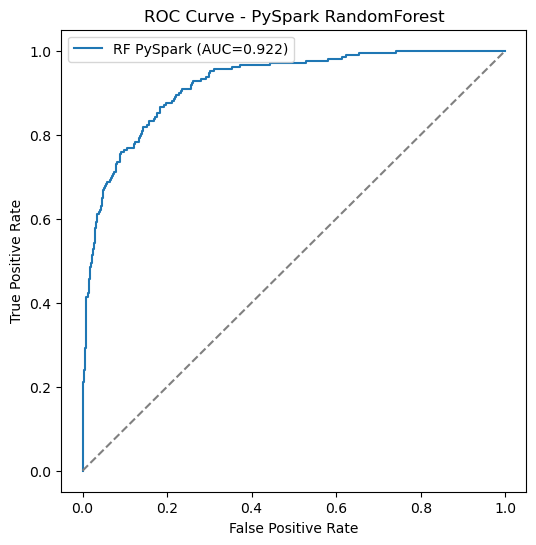

In [50]:
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="RF PySpark (AUC={:.3f})".format(metrics["roc_auc"]))
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PySpark RandomForest")
plt.legend()
plt.show()

## LIME

#### Librerias Necesarias

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

### Seleccionamos muestras

In [52]:
import numpy as np

N = 1500  # ajusta si quieres
sample = (preds
          .select("features", F.col("label").cast("double").alias("label"))
          .orderBy(F.rand(42))
          .limit(N)
          .cache())

rows = sample.collect()
X = np.vstack([np.array(r['features']) for r in rows])  # (n, d)
y = np.array([r['label'] for r in rows], dtype=float)   # (n,)


In [53]:
from pyspark.sql import functions as F

# Usaremos preds (o el df de train) para leer el metadata del vector
meta = preds.schema['features'].metadata
attrs = []
for k in ['numeric', 'binary']:  # VectorAssembler guarda attrs por tipo
    if k in meta.get('ml_attr', {}).get('attrs', {}):
        attrs += meta['ml_attr']['attrs'][k]
feature_names = [a['name'] for a in sorted(attrs, key=lambda x: x['idx'])]


In [54]:
from pyspark.ml.linalg import DenseVector

# Último stage = RandomForestClassificationModel
rf_model = model_pipe.stages[-1]

def rf_predict_proba(X_batch: np.ndarray) -> np.ndarray:
    """Devuelve probabilidades (n,2) usando el modelo Spark localmente (rápido)."""
    out = np.zeros((X_batch.shape[0], 2), dtype=float)
    for i, row in enumerate(X_batch):
        pv = rf_model.predictProbability(DenseVector(row))  # vector MLlib
        out[i, 0] = float(pv[0])
        out[i, 1] = float(pv[1])
    return out


In [55]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X,
    feature_names=feature_names,
    class_names=['no_incumple', 'incumple'],  # ajusta a tu caso 0/1
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Elige una fila (p.ej. una mal clasificada)
# i = 0  # o…
err = (preds
       .select("features","label","prediction")
       .where(F.col("label") != F.col("prediction"))
       .limit(1)
       .collect())

if err:
    x_star = np.array(err[0]["features"])     # vector de la instancia
else:
    x_star = X[0]  # si no hay errores, toma la primera

exp = explainer.explain_instance(
    data_row=x_star,
    predict_fn=rf_predict_proba,
    num_features=10,      # top-10 contribuciones
    top_labels=1
)

# Texto (pares feature, contribución)
print(exp.as_list(label=exp.available_labels()[0]))
  # explica hacia la clase 1 (incumple)


[('last_fico_range_high_oh_499.0 <= 0.00', 0.10165681695162482), ('last_fico_range_high_oh_514.0 <= 0.00', 0.08547745330504763), ('last_fico_range_high_oh_509.0 <= 0.00', 0.07734597090650912), ('last_fico_range_high_oh_504.0 <= 0.00', 0.07728600764262672), ('last_fico_range_high_oh_534.0 <= 0.00', 0.0743112995174103), ('last_fico_range_high_oh_519.0 <= 0.00', 0.06847239593730185), ('last_fico_range_high_oh_579.0 <= 0.00', 0.06845266611296066), ('last_fico_range_high_oh_529.0 <= 0.00', 0.06639670263619783), ('last_fico_range_high_oh_559.0 <= 0.00', 0.06185798039595126), ('last_fico_range_high_oh_524.0 <= 0.00', 0.06077905940540307)]


### Nombres de features

### Explainer

### Instancias mal clasificadas del test